# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on July 20th (with 2-hour grace period)

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [72]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression


# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [73]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


In [74]:
df.describe()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,assessmentyear,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
count,7.761300e+04,25007.000000,207.000000,50.000000,77579.000000,77579.000000,15.000000,49809.000000,76963.000000,614.0,...,223.000000,50703.000000,2393.000000,70.000000,77309.000000,17599.000000,77579.0,2900.000000,7.733200e+04,7.757800e+04
mean,1.300781e+07,1.812013,7.386473,679.720000,2.298496,3.053223,3.933333,6.533779,2.316392,66.0,...,6.040359,1.110309,305.460928,216.385714,1968.611507,1.434286,2016.0,14.088276,6.049667e+13,4.901506e+05
std,3.518717e+06,2.965768,2.728030,689.703546,0.996732,1.140480,0.258199,1.722062,0.979689,0.0,...,0.556035,1.169967,238.735241,190.177514,23.793171,0.544515,0.0,2.181281,1.533339e+12,6.537979e+05
min,1.071186e+07,1.000000,2.000000,38.000000,0.000000,0.000000,3.000000,1.000000,1.000000,66.0,...,4.000000,1.000000,11.000000,12.000000,1824.000000,1.000000,2016.0,3.000000,6.037101e+13,1.000000e+03
25%,1.153821e+07,1.000000,7.000000,273.000000,2.000000,2.000000,4.000000,6.000000,2.000000,66.0,...,6.000000,1.000000,170.000000,61.500000,1953.000000,1.000000,2016.0,14.000000,6.037311e+13,2.068985e+05
50%,1.253004e+07,1.000000,7.000000,515.000000,2.000000,3.000000,4.000000,6.000000,2.000000,66.0,...,6.000000,1.000000,250.000000,164.500000,1970.000000,1.000000,2016.0,15.000000,6.037603e+13,3.588785e+05
75%,1.421101e+07,1.000000,7.000000,796.500000,3.000000,4.000000,4.000000,8.000000,3.000000,66.0,...,6.000000,1.000000,364.000000,310.500000,1987.000000,2.000000,2016.0,15.000000,6.059042e+13,5.690000e+05
max,1.676893e+08,13.000000,21.000000,3560.000000,18.000000,16.000000,4.000000,12.000000,18.000000,66.0,...,13.000000,237.000000,3191.000000,868.000000,2016.000000,6.000000,2016.0,99.000000,4.830301e+14,4.906124e+07


In [75]:
df.shape

(77613, 55)

In [76]:
df.isnull().sum()


parcelid                            0
airconditioningtypeid           52606
architecturalstyletypeid        77406
basementsqft                    77563
bathroomcnt                        34
bedroomcnt                         34
buildingclasstypeid             77598
buildingqualitytypeid           27804
calculatedbathnbr                 650
decktypeid                      76999
finishedfloor1squarefeet        71576
calculatedfinishedsquarefeet      235
finishedsquarefeet12             3690
finishedsquarefeet13            77571
finishedsquarefeet15            74586
finishedsquarefeet50            71576
finishedsquarefeet6             77227
fips                               34
fireplacecnt                    69324
fullbathcnt                       650
garagecarcnt                    52093
garagetotalsqft                 52093
hashottuborspa                  76074
heatingorsystemtypeid           28042
latitude                           34
longitude                          34
lotsizesquar

In [77]:
#Create Regression Model

#Copy of dataframe
df_copy = df.copy()

#Selecting numeric columns
df_copy_numeric = df.select_dtypes(include=['float64', 'int64'])

#Imputer
imputer = SimpleImputer(strategy= 'median')
df_imputer = pd.DataFrame(imputer.fit_transform(df_copy_numeric), columns= df_copy_numeric.columns)


#Dropping target col and defining X and y
X = df_imputer.drop(columns= 'taxvaluedollarcnt')
y = df_imputer['taxvaluedollarcnt']

print(f"Shape of data after imputing = {X.shape}")

#Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

#Model
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

#Predict
y_pred = model.predict(X_test)

#MSE, RMSE, MAE
mse = mean_squared_error(y_test, y_pred)
print(f"MSE = {mse:,.2f}")

rmse = np.sqrt(mse)
print(f"RMSE = ${rmse:,.2f}")

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE = ${mae:,.2f}")


Shape of data after imputing = (77613, 49)
MSE = 170,122,217,081.97
RMSE = $412,458.75
MAE = $203,073.23


In [78]:
#Presentation of results

print('Zillow Housing Dataset Results')
print('-------------------------------------')
print('Dataset Overview: \n'
      '- The Zillow Housing Dataset contains 77,613 values and 55 features. \n'
      '- Some key features include: Size (lotsizesquarefeet, bedroomcnt, bathroomcnt), Year Built (yearbuilt), Location (regionidcity, regionidcounty), etc'
      '- The target variable in the dataset is (taxvaluedollarcnt), which represents the total assessed value of the property in dollars'
      '- Dataset contains missing values, which was handled using median imputation')
print('-------------------------------------')
print('Objective: \n'
      '- Our objective is to utilize regression models to obtain a more accurate prediction of total assessed property values using features that detail \n'
      'property size, location, year the property was built, amenities, etc')
print('-------------------------------------')
print('Solution: \n'
      '- We used Gradient Boosting Regression as our regression model due to its high accuracy and ability to handle missing data'
      '- Numeric features were only selected and missing values were handled using median imputation'
      '- Model was trained using 80 percent of the data and tested on 20 percent')
print('-------------------------------------')
print('Results: \n'
      '- We calculated the following: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE)'
      '- The resulting MSE from our model came out to be 170,122,217,081'
      '- The resulting RMSE from our model came out to be $412,459'
      '- The resulting MAE from our model came out to be $203,073')
print('-------------------------------------')
print('Interpreting Results \n'
      '- We can see that RMSE is double that of the MAE. This suggests that most of the model predictions are accurate, however there are some predictions \n'
      '  that are significantly off. Due to this, we see a higher RMSE than the MAE. \n'
      '- Our model is off by an average of $203k (MAE) and most of the predictions are around $413K (RMSE) from the actual values. This is reasonable \n'
      '  because of the wide range of property values within our dataset')
print('-------------------------------------')
print('Conclusion \n'
      '- From our results, we can say that our model provides us with a good starting point in predicting total assessed property values. However, \n'
      '  improvements such as hyperparameter tuning and handling significant outliers is required to make the model more accurate and reliable.')


Zillow Housing Dataset Results
-------------------------------------
Dataset Overview: 
- The Zillow Housing Dataset contains 77,613 values and 55 features. 
- Some key features include: Size (lotsizesquarefeet, bedroomcnt, bathroomcnt), Year Built (yearbuilt), Location (regionidcity, regionidcounty), etc- The target variable in the dataset is (taxvaluedollarcnt), which represents the total assessed value of the property in dollars- Dataset contains missing values, which was handled using median imputation
-------------------------------------
Objective: 
- Our objective is to utilize regression models to obtain a more accurate prediction of total assessed property values using features that detail 
property size, location, year the property was built, amenities, etc
-------------------------------------
Solution: 
- We used Gradient Boosting Regression as our regression model due to its high accuracy and ability to handle missing data- Numeric features were only selected and missing v

**1.1:**  What is the objective of this project in business terms?


The objective of this project in business terms is to obtain more accurate house price estimates through regression models based on different features (such as number of bedrooms, location, year it was built, etc.). More accurate house price predictions will help Zillow attract more clients, as customers will recommend products they like to others.

**1.2:**  How will your solution be used?


A well trained regression model will utilize important features in this dataset to estimate house prices. Other feature values can also be used to observe which ones have a greater impact on house prices in different regions and locations.

**1.3:**  How should success (or failure) be measured?


Success should be measured by the performance of the model on new dataset by using the techniques like MSE, MAE, RMSE, etc. And a low score on these evaluation metrics would be good, a higher score on the prediction score would be good for the model. In this case, the more accurate the prediction score for house prices, the better the measure of success.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [79]:
df.head(10)

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0
5,17143294,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1982.0,2.0,NaN,2016.0,NaN,NaN,6.111005e+13,331064.0
6,12095076,1.0,NaN,NaN,3.0,4.0,NaN,9.0,3.0,NaN,...,NaN,NaN,1950.0,NaN,NaN,2016.0,NaN,NaN,6.037461e+13,773303.0
7,12069064,NaN,NaN,NaN,1.0,2.0,NaN,5.0,1.0,NaN,...,NaN,NaN,1922.0,NaN,NaN,2016.0,NaN,NaN,6.037302e+13,218552.0
8,12790562,NaN,NaN,NaN,3.0,4.0,NaN,9.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037500e+13,220583.0
9,11542646,NaN,NaN,NaN,3.0,2.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1980.0,NaN,NaN,2016.0,NaN,NaN,6.037275e+13,371361.0


In [80]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [81]:
df.nunique().sort_values()

decktypeid                          1
pooltypeid7                         1
pooltypeid2                         1
pooltypeid10                        1
poolcnt                             1
hashottuborspa                      1
taxdelinquencyflag                  1
storytypeid                         1
fireplaceflag                       1
assessmentyear                      1
buildingclasstypeid                 2
regionidcounty                      3
fips                                3
typeconstructiontypeid              4
numberofstories                     4
threequarterbathnbr                 4
architecturalstyletypeid            5
fireplacecnt                        5
airconditioningtypeid               5
unitcnt                             8
heatingorsystemtypeid              10
buildingqualitytypeid              12
propertylandusetypeid              13
taxdelinquencyyear                 13
fullbathcnt                        13
finishedsquarefeet13               13
garagecarcnt

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [83]:
missing_values = df.isnull().sum()
print(missing_values)

parcelid                            0
airconditioningtypeid           52606
architecturalstyletypeid        77406
basementsqft                    77563
bathroomcnt                        34
bedroomcnt                         34
buildingclasstypeid             77598
buildingqualitytypeid           27804
calculatedbathnbr                 650
decktypeid                      76999
finishedfloor1squarefeet        71576
calculatedfinishedsquarefeet      235
finishedsquarefeet12             3690
finishedsquarefeet13            77571
finishedsquarefeet15            74586
finishedsquarefeet50            71576
finishedsquarefeet6             77227
fips                               34
fireplacecnt                    69324
fullbathcnt                       650
garagecarcnt                    52093
garagetotalsqft                 52093
hashottuborspa                  76074
heatingorsystemtypeid           28042
latitude                           34
longitude                          34
lotsizesquar

In [84]:
percent_missing = (missing_values / len(df)) * 100
print(percent_missing)

parcelid                         0.000000
airconditioningtypeid           67.779882
architecturalstyletypeid        99.733292
basementsqft                    99.935578
bathroomcnt                      0.043807
bedroomcnt                       0.043807
buildingclasstypeid             99.980673
buildingqualitytypeid           35.823895
calculatedbathnbr                0.837489
decktypeid                      99.208895
finishedfloor1squarefeet        92.221664
calculatedfinishedsquarefeet     0.302784
finishedsquarefeet12             4.754358
finishedsquarefeet13            99.945885
finishedsquarefeet15            96.099880
finishedsquarefeet50            92.221664
finishedsquarefeet6             99.502661
fips                             0.043807
fireplacecnt                    89.320088
fullbathcnt                      0.837489
garagecarcnt                    67.118910
garagetotalsqft                 67.118910
hashottuborspa                  98.017085
heatingorsystemtypeid           36

In [85]:
df.select_dtypes(include=['object']).columns.tolist() # getting categorical columns

['hashottuborspa',
 'propertycountylandusecode',
 'propertyzoningdesc',
 'fireplaceflag',
 'taxdelinquencyflag']

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Features like hashottuborspa, propertycountylandusecode, propertyzoningdesc, fireplaceflag, taxdelinquencyflag are categorical.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

Features like parcelid, fireplaceflag are should be deleted. For parcelid, it is just a unique identifier and has little meaning. For fireplaceflag, it has the same meaning as fireplacecnt, if fireplacecnt has at least one value, then fireplaceflag will be true, so it is redundant

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

Featues like basementsqft, buildingclasstypeid, finishedsquarefeet13, storytypeid, yearbuildingsqft26 could be useless because of the percentage of missing values. The dataset has a total of 77613 rows with more than 90% missing values for these features.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

Features like decktypeid, storytpeid, assessmentyear and fireplaceflag appear to be useless because of the number of unique values. For decktypeid it only has two values, nan and 66, it doesn't tell too much information. For assessmentyear, it tells you the year of the assessment which is 2016, kind of meaningless.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

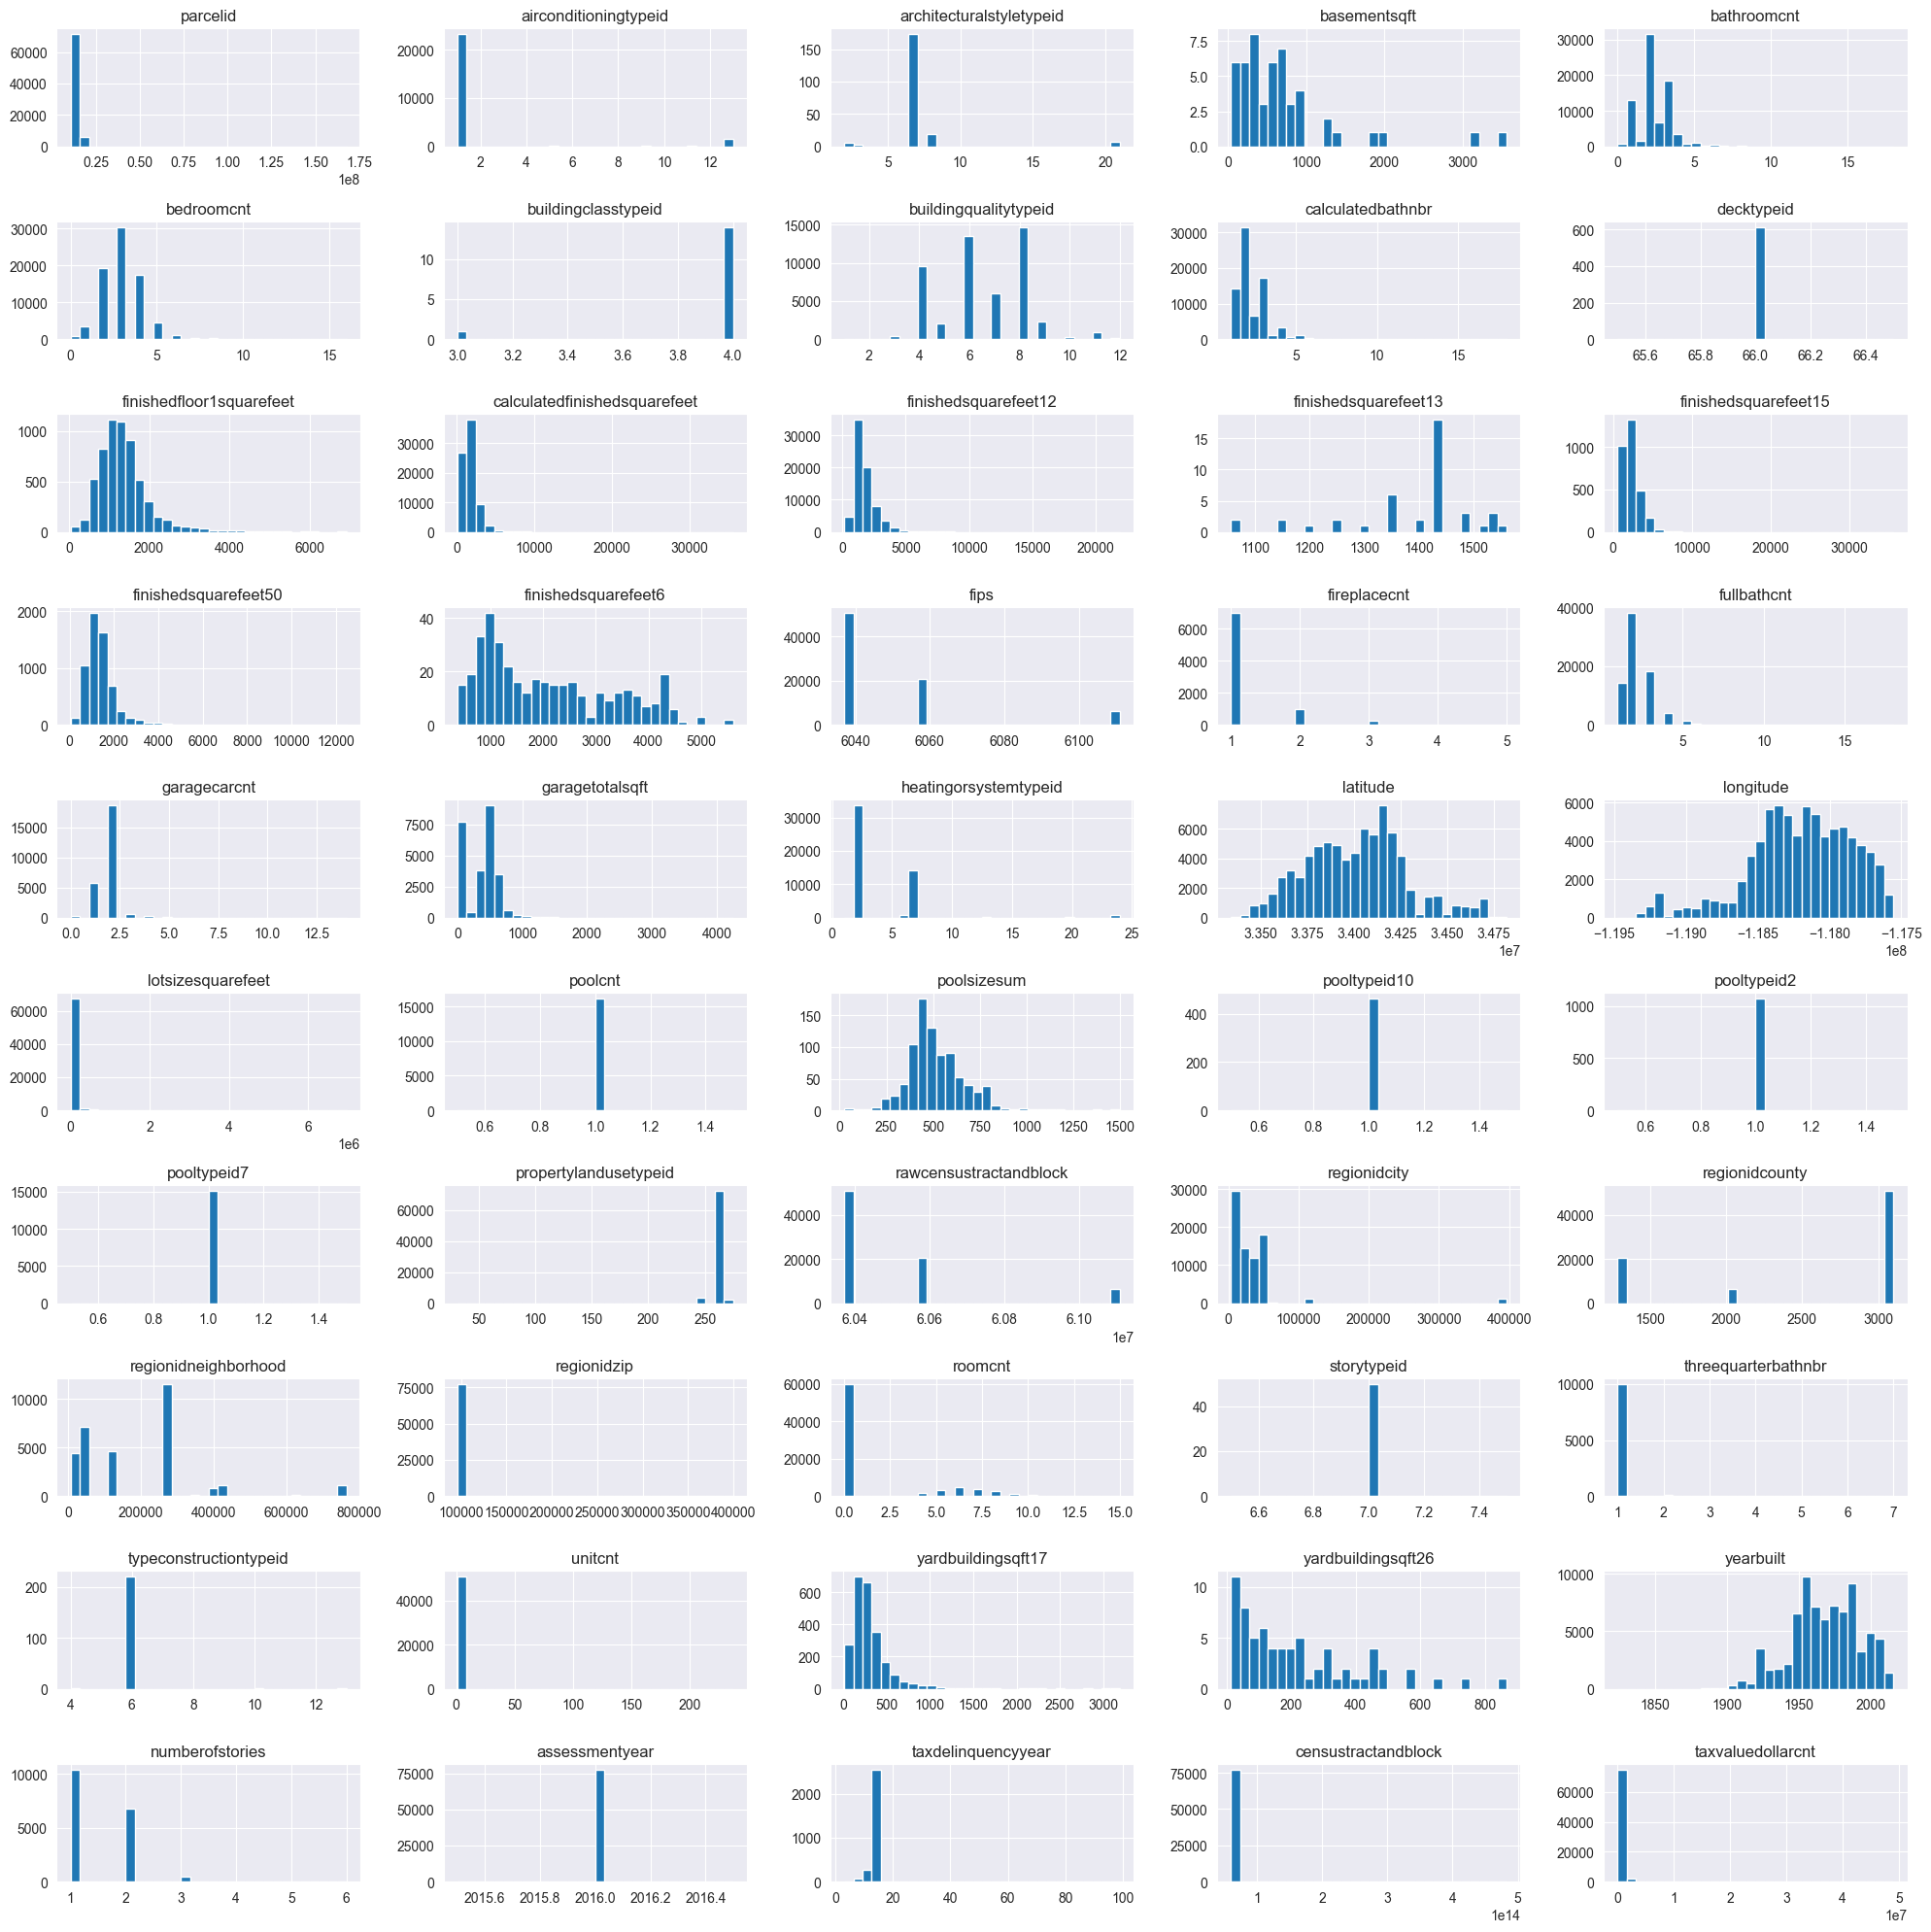

In [86]:
df.hist(figsize=(20, 20), layout=(-1, 5), bins=30)
plt.tight_layout()
plt.show()

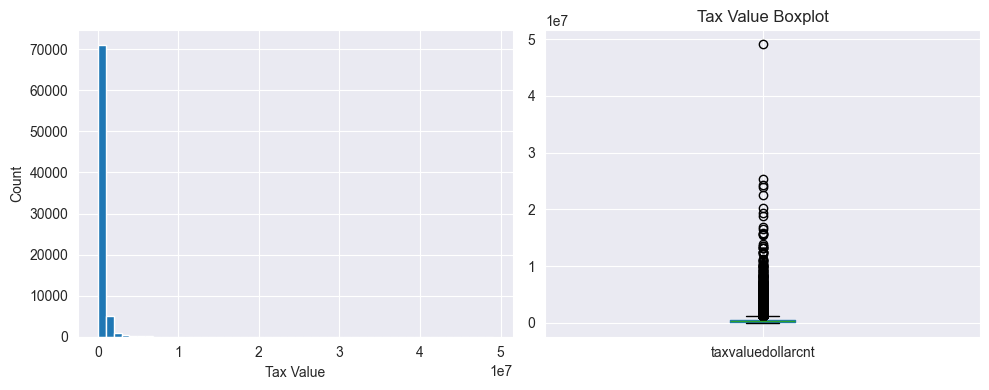

In [87]:
#show two plots, one is the taxvaluedollarcnt histogram, the other one is the taxcaluedollarcnt boxplot.
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['taxvaluedollarcnt'].hist(bins=50)
plt.ylabel('Count')
plt.xlabel('Tax Value')

plt.subplot(1, 2, 2)
df.boxplot(column='taxvaluedollarcnt')
plt.title('Tax Value Boxplot')

plt.tight_layout()
plt.show()

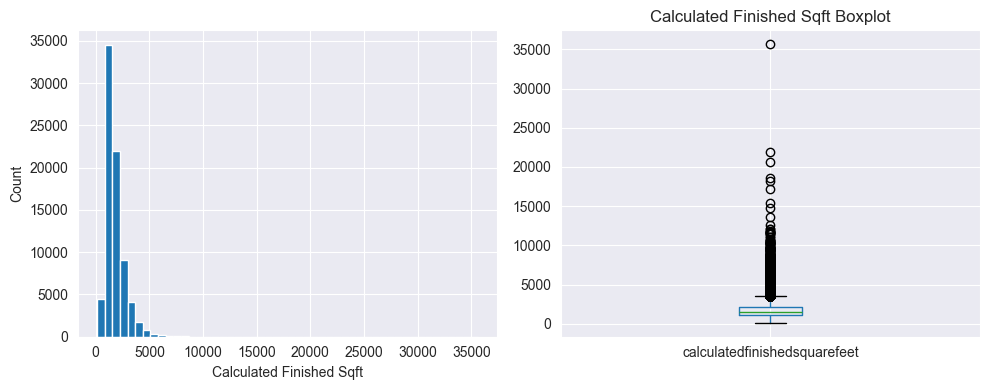

In [88]:
#show calculatedfinishedsquarefeet histogram and boxplot.
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['calculatedfinishedsquarefeet'].hist(bins=50)
plt.ylabel('Count')
plt.xlabel('Calculated Finished Sqft')

plt.subplot(1, 2, 2)
df.boxplot(column='calculatedfinishedsquarefeet')
plt.title('Calculated Finished Sqft Boxplot')

plt.tight_layout()
plt.show()

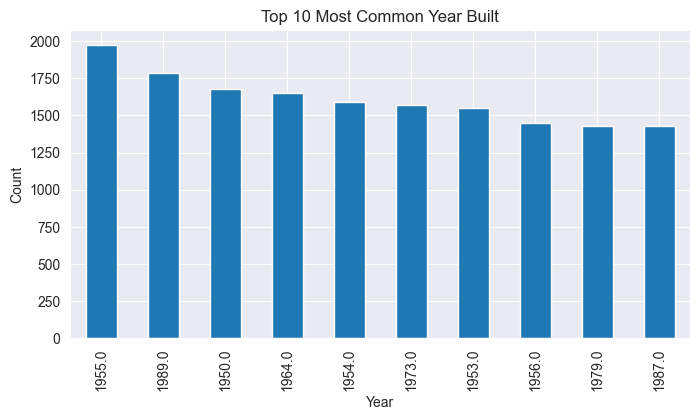

In [89]:
#Show the 10 counts with the most years of built.
top_zips = df['yearbuilt'].value_counts().head(10)
top_zips.plot(kind='bar', figsize=(8, 4))
plt.title('Top 10 Most Common Year Built')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

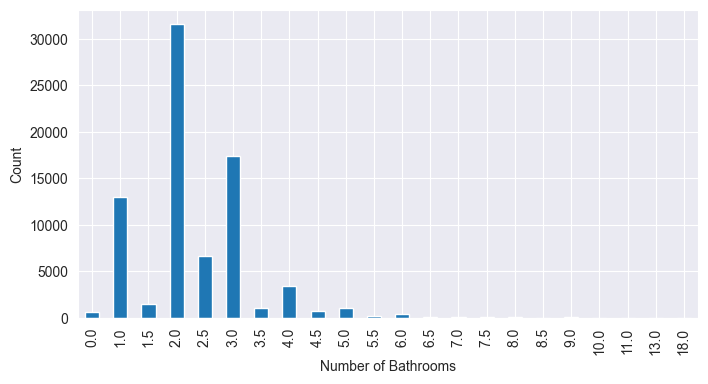

In [90]:
#show the number of bathrooms distribution of a house
df['bathroomcnt'].value_counts().sort_index().plot(kind='bar', figsize=(8, 4))
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count')
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


For the target and calculatedfinishedsquarefeet plots, they are right-skewed distribution, and yearbuilt plot is a uniform distribution.
In the plot based on the target feature, the outlier point is at the top of the plot, while the majority of the points are at the bottom of the plot, between 1e7 and 0. This can result in a regression model that performs poorly on a normal dataset while the RMSE scores are high, which is very bad to see. The calculatedfinishedsquarefeet feature is the same as the target feature, and the outlier at the top of the plot may be the same as the results for the target feature.
Houses of 1000 - 2000 finished square feet are the most common, as well as larger houses of over 35000 square feet. The top 10 most common years built are in the 1900's and can be described as being of perfect construction or quality. Most houses have two bathrooms and are over 30000 counts, and there are a few houses that have 6 bathrooms, which must have something to do with the fact that the houses are over 35000 square feet.
These were chosen as these features are significant indicators of total assessment value of a property. This examination suggests the possibility of using log transformations to improve the regression model performance. 

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [92]:
df.drop(columns=['parcelid', 'assessmentyear', 'regionidcity', 'taxdelinquencyyear', 'fireplaceflag', 'finishedfloor1squarefeet', 'finishedsquarefeet12', 'finishedsquarefeet50', 'finishedsquarefeet6', 'regionidneighborhood', 'censustractandblock', 'finishedsquarefeet13', 'pooltypeid10', 'finishedsquarefeet15'], inplace=True)

#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


Since parcelid is just the unique identifier, it doesn't have anything to do with the model. For assessmentyear are all value 2016, there is no difference between each other, could drop that. The regionidcity has the same functionality with regionidcountry, even though they represent different meaning. The taxdelinquencyyear has the same missing values with taxdelinguencyflag, they represent the same thing, so could drop one of them. For finishedsquarefeet13, even it's perimeter of finished living area footage, but we have total area and the finished living area footage, it's kinda useless and has a lot of missing values. For pooltypeid10 and finishedsquarefeet15, it's the same as the finishedsquarefeet13. For fireplaceflag, kinda conflicts with fireplacecnt, if a house has a fireplace then the fireplaceflag would flag true in this case, redundant and contains 'too many' null values. The finishedfloor1squarefeet, finishedsquarefeet12/50/6 are kinda useless, since we already have total area and the total finished living area square footage. Since we have lat and long, regionidneighborhood is kind of useless. The rawcensustractandblock is similar with censustractandblock, so could drop one of those.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [93]:
threshold = 0.5

percent_missing = df.isnull().mean()

cols_exceed_thres = percent_missing[percent_missing > threshold].index.tolist()
print(f'Columns with more than 50% of missing values:', cols_exceed_thres)

Columns with more than 50% of missing values: ['airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'regionidneighborhood', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'numberofstories', 'fireplaceflag', 'taxdelinquencyflag']


In [94]:
df.drop(columns=['decktypeid', 'storytypeid', 'architecturalstyletypeid', 'buildingclasstypeid', 'typeconstructiontypeid'], inplace=True)

#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



For decktypeid and storytypeid only got two values, nan and a numeric value, it can be interpreted as no for nan and yes for that numeric value, most of them are nan. Most of the storytypeid are missing, it can be said most of the houses are unknown story type. For architecturalstyletypeid, most of the values are null values, those null values could represent unknown type or the same type of style of the property, not too helpful. For buildingclasstypeid, the same reason as architecturalstyletypeid. For typeconstructiontypeid, most of the values are missing.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [ ]:
df.drop(columns=[], inplace=True)


In [96]:
df = df.dropna(subset=['taxvaluedollarcnt']) # dropping samples where taxvaluedollarcnt (target) is NaN
threshold = 0.9
df = df[df.isnull().mean(axis=1) < threshold] # dropping samples with more than 90% missing values
# Remove outliers in 'taxvaluedollarcnt' using IQR method
Q1 = df['taxvaluedollarcnt'].quantile(0.25)
Q3 = df['taxvaluedollarcnt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['taxvaluedollarcnt'] >= lower_bound) & (df['taxvaluedollarcnt'] <= upper_bound)]
df

,airconditioningtypeid,basementsqft,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,fips,fireplacecnt,fullbathcnt,...,regionidzip,roomcnt,threequarterbathnbr,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,taxdelinquencyflag,taxvaluedollarcnt
0,NaN,NaN,3.5,4.0,NaN,3.5,3100.0,6059.0,NaN,3.0,...,96978.0,0.0,1.0,NaN,NaN,NaN,1998.0,NaN,NaN,1023282.0
1,NaN,NaN,1.0,2.0,NaN,1.0,1465.0,6111.0,1.0,1.0,...,97099.0,5.0,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,464000.0
2,NaN,NaN,2.0,3.0,NaN,2.0,1243.0,6059.0,NaN,2.0,...,97078.0,6.0,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,564778.0
3,NaN,NaN,3.0,4.0,8.0,3.0,2376.0,6037.0,NaN,3.0,...,96330.0,0.0,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,145143.0
4,1.0,NaN,3.0,3.0,8.0,3.0,1312.0,6037.0,NaN,3.0,...,96451.0,0.0,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,119407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77608,1.0,NaN,3.0,3.0,8.0,3.0,1741.0,6037.0,NaN,3.0,...,96415.0,0.0,NaN,1.0,NaN,NaN,1980.0,NaN,NaN,379000.0
77609,NaN,NaN,2.0,2.0,6.0,2.0,1286.0,6037.0,NaN,2.0,...,96284.0,0.0,NaN,1.0,NaN,NaN,1940.0,NaN,NaN,354621.0
77610,NaN,NaN,2.0,4.0,NaN,2.0,1612.0,6111.0,1.0,2.0,...,97116.0,7.0,NaN,NaN,656.0,NaN,1964.0,1.0,NaN,67205.0
77611,1.0,NaN,1.0,3.0,4.0,1.0,1032.0,6037.0,NaN,1.0,...,96480.0,0.0,NaN,1.0,NaN,NaN,1954.0,NaN,NaN,49546.0


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


We chose to drop samples with missing values in the target ('taxvaluedollarcnt'), samples with more than 90% nulls, and samples where the target was an extreme outlier (based on the IQR rule).

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [97]:
def fill0(df, col):
    df[col] = df[col].fillna(0)
    return df

In [98]:
df = df.dropna(subset=['taxvaluedollarcnt'])

for col in ['garagecarcnt', 'fireplacecnt', 'airconditioningtypeid', 'basementsqft', 'taxdelinquencyflag', 'garagetotalsqft', 'hashottuborspa', 'poolcnt', 'pooltypeid2', 'pooltypeid7', 'threequarterbathnbr', 'yardbuildingsqft26', 'yardbuildingsqft17']:
    df = fill0(df, col)

df['taxdelinquencyflag'] = df['taxdelinquencyflag'].replace('Y', 1).astype(int)
df['hashottuborspa'] = df['hashottuborspa'].replace('True', 1).astype(int)
df['unitcnt'] = df['unitcnt'].fillna(1)
df['numberofstories'] = df['numberofstories'].fillna(1)
df.loc[df['poolcnt'] == 0, 'poolsizesum'] = 0


C:\Users\taixi\AppData\Local\Temp\ipykernel_10348\373903317.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['taxdelinquencyflag'] = df['taxdelinquencyflag'].replace('Y', 1).astype(int)


In [99]:
for col in ['yearbuilt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fullbathcnt', 'lotsizesquarefeet']:
    df[col] = df[col].fillna(df[col].median())
df['poolsizesum'] = df['poolsizesum'].fillna(df['poolsizesum'].median())

for col in ['buildingqualitytypeid', 'propertyzoningdesc', 'regionidzip', 'heatingorsystemtypeid']:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

In [100]:
df.isnull().sum()

airconditioningtypeid           0
basementsqft                    0
bathroomcnt                     0
bedroomcnt                      0
buildingqualitytypeid           0
calculatedbathnbr               0
calculatedfinishedsquarefeet    0
fips                            0
fireplacecnt                    0
fullbathcnt                     0
garagecarcnt                    0
garagetotalsqft                 0
hashottuborspa                  0
heatingorsystemtypeid           0
latitude                        0
longitude                       0
lotsizesquarefeet               0
poolcnt                         0
poolsizesum                     0
pooltypeid2                     0
pooltypeid7                     0
propertycountylandusecode       0
propertylandusetypeid           0
propertyzoningdesc              0
rawcensustractandblock          0
regionidcounty                  0
regionidzip                     0
roomcnt                         0
threequarterbathnbr             0
unitcnt       

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


First, use the dropna to keep the non-null values in the target feature, taxvaluedollarcnt. Then use fillna with value 0 to fill the missing value in those columns because missing values in those columns represent don't have that value, for example in fireplacecnt, nan could means there is no fireplace in that house, so we could replace nan with 0 to represent doesn't have a fireplace. The reset is done with the same logic, replace string like 'Y' and 'True' to 1.

For those columns fill with median because most of them are numerical and non-categorical data type, so median method is more appropriate.

For those columns fill with mode because they are more like categorical data type, like regionidzip can't fill with any specific value or median value, so mode could just give a common value to it.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [101]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_features)

['propertycountylandusecode', 'propertyzoningdesc']


In [102]:
df_one_hot_encoding = pd.get_dummies(df, columns=['propertycountylandusecode', 'propertyzoningdesc'], drop_first=True)

In [103]:
print(df_one_hot_encoding.columns)

Index(['airconditioningtypeid', 'basementsqft', 'bathroomcnt', 'bedroomcnt',
       'buildingqualitytypeid', 'calculatedbathnbr',
       'calculatedfinishedsquarefeet', 'fips', 'fireplacecnt', 'fullbathcnt',
       ...
       'propertyzoningdesc_WVRPD112U*', 'propertyzoningdesc_WVRPD12000',
       'propertyzoningdesc_WVRPD12U*', 'propertyzoningdesc_WVRPD12U-R',
       'propertyzoningdesc_WVRPD17U*', 'propertyzoningdesc_WVRPD18U*',
       'propertyzoningdesc_WVRPD40000', 'propertyzoningdesc_WVRPD4OOOO',
       'propertyzoningdesc_WVRR', 'propertyzoningdesc_WVRR1-RPD1'],
      dtype='object', length=1933)


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

## Correlation heatmap

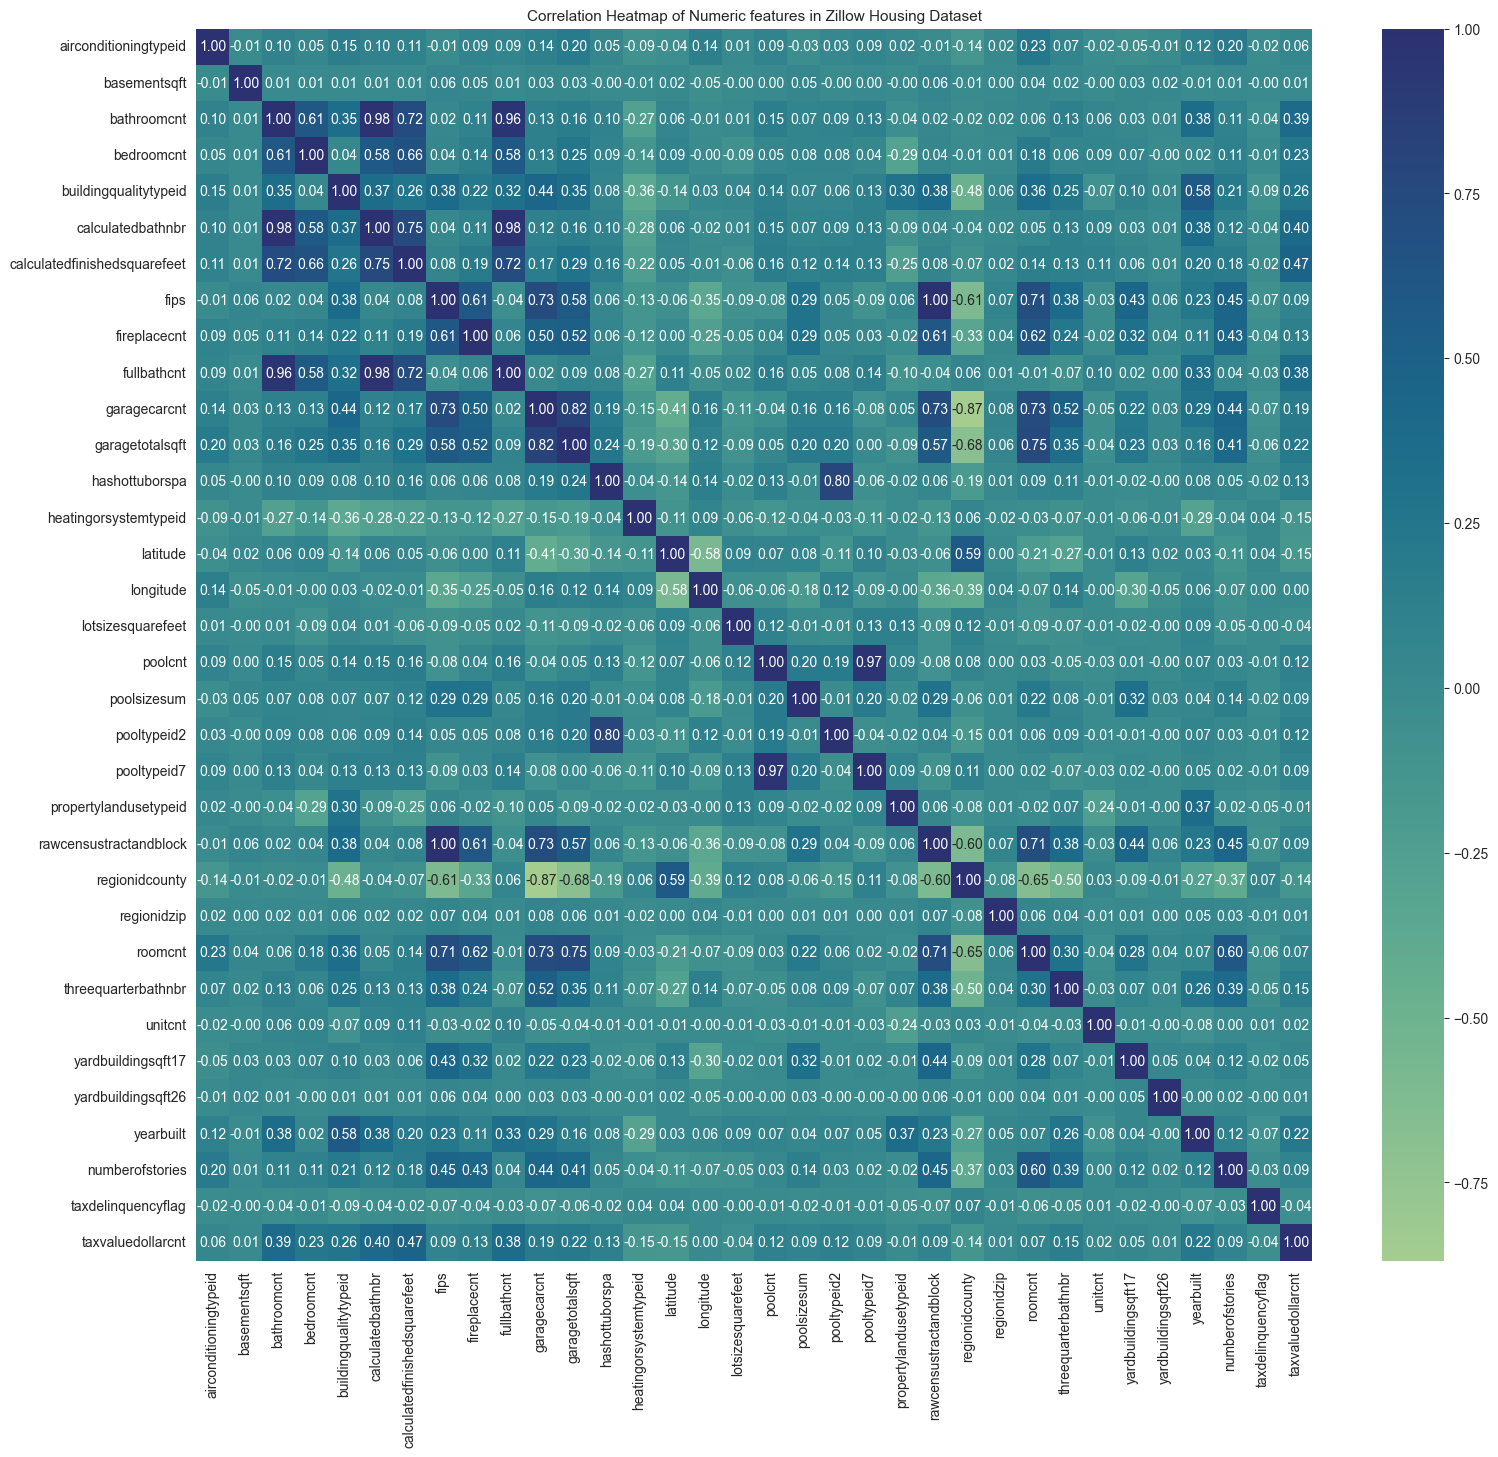

In [104]:
numeric = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric.corr()

plt.figure(figsize=(18, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='crest')
plt.title('Correlation Heatmap of Numeric features in Zillow Housing Dataset', fontsize= 11)
plt.show()

## Bar chart F statistic for all features

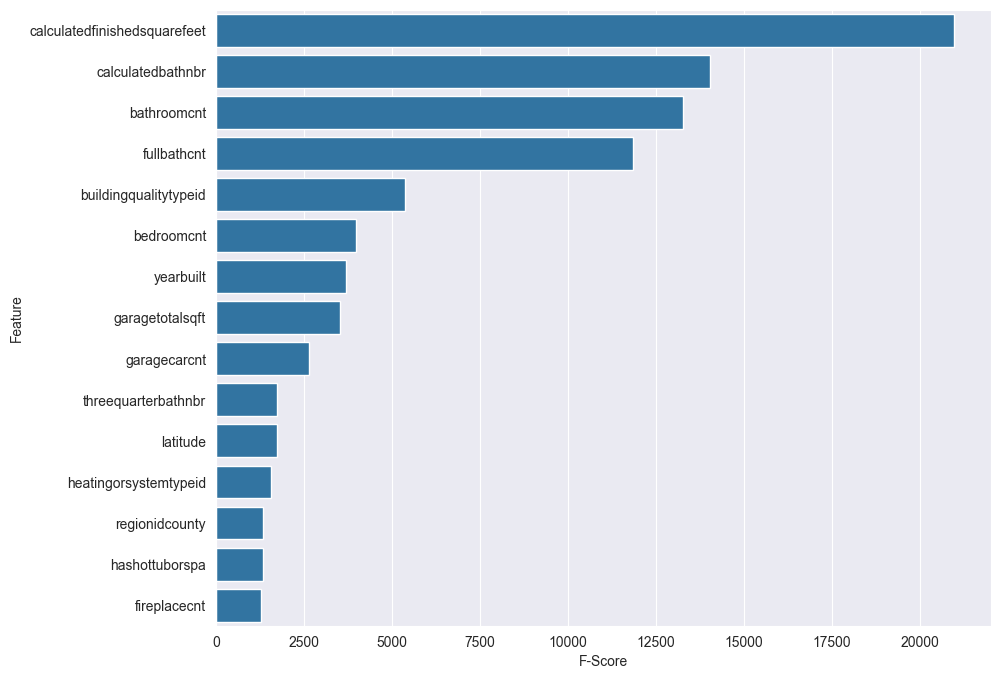

In [105]:
X = numeric.drop(columns = ['taxvaluedollarcnt'])
y = numeric['taxvaluedollarcnt']

f_scores, p_values = f_regression(X.fillna(0), y)

f_result = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_scores,
    'P-Value': p_values
}).sort_values(by='F-Score', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=f_result.head(15), x='F-Score', y='Feature')
plt.show()

## Top 15 positively and negatively correlated features with target

Top positively correlated features:
 taxvaluedollarcnt               1.000000
calculatedfinishedsquarefeet    0.473957
calculatedbathnbr               0.403048
bathroomcnt                     0.393566
fullbathcnt                     0.375151
buildingqualitytypeid           0.262660
bedroomcnt                      0.228131
yearbuilt                       0.220821
garagetotalsqft                 0.215189
garagecarcnt                    0.187730
Name: taxvaluedollarcnt, dtype: float64

Top negatively correlated features:
 yardbuildingsqft26       0.010199
basementsqft             0.008578
regionidzip              0.005771
longitude                0.001487
propertylandusetypeid   -0.008251
taxdelinquencyflag      -0.037227
lotsizesquarefeet       -0.043710
regionidcounty          -0.135026
heatingorsystemtypeid   -0.145074
latitude                -0.153080
Name: taxvaluedollarcnt, dtype: float64


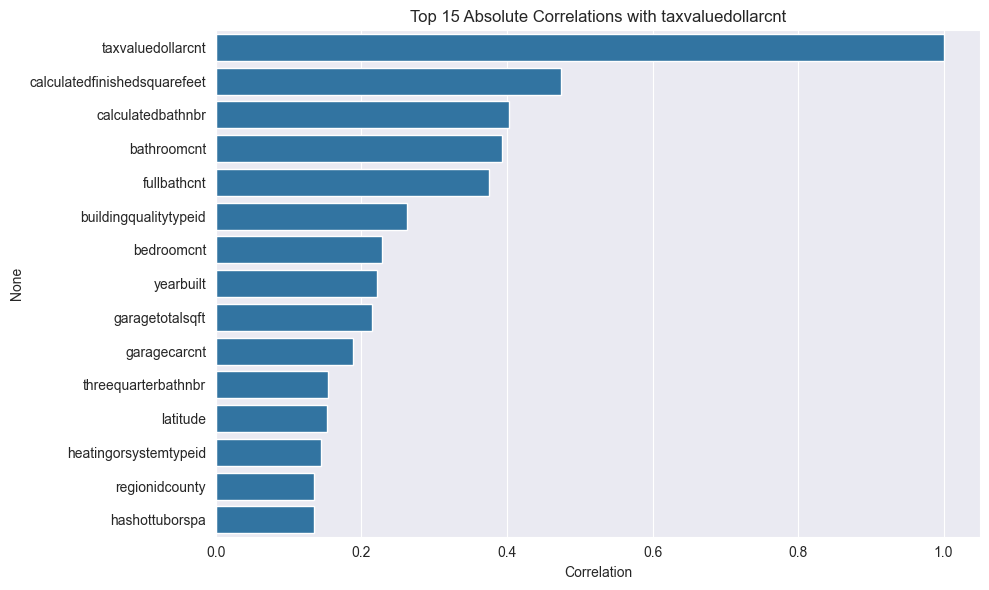

In [106]:

correlation_target = corr_matrix['taxvaluedollarcnt'].sort_values(ascending=False)

print("Top positively correlated features:\n", correlation_target.head(10))
print("\nTop negatively correlated features:\n", correlation_target.tail(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_target.abs().sort_values(ascending=False).head(15), y=correlation_target.abs().sort_values(ascending=False).head(15).index)
plt.title("Top 15 Absolute Correlations with taxvaluedollarcnt")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()


The plot shows that features like calculatedfinishedsquarefeet, calculatedbathnbr, and bathroomcnt have strong correlations with taxvaluedollarcnt. It suggests that properties with more bathrooms and larger square footage tend to have higher values. It's interesting, number of bathrooms seems to be more important than number of bedrooms

In [107]:
model = df.dropna(subset=['taxvaluedollarcnt'])
X = model.drop(columns=['taxvaluedollarcnt'])
y = model['taxvaluedollarcnt']


X = X.select_dtypes(include='number').dropna(axis=1)

# Forward
forward_selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=10, direction='forward')
forward_selector.fit(X, y)
print("Forward selected features:", list(X.columns[forward_selector.get_support()]))

# Backward
backward_selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=10, direction='backward')
backward_selector.fit(X, y)
print("Backward selected features:", list(X.columns[backward_selector.get_support()]))


Forward selected features: ['bathroomcnt', 'bedroomcnt', 'calculatedfinishedsquarefeet', 'garagetotalsqft', 'latitude', 'longitude', 'poolsizesum', 'propertylandusetypeid', 'roomcnt', 'yearbuilt']
Backward selected features: ['bathroomcnt', 'bedroomcnt', 'calculatedfinishedsquarefeet', 'fips', 'garagetotalsqft', 'latitude', 'longitude', 'rawcensustractandblock', 'roomcnt', 'yearbuilt']


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The top three features most strongly correlated with the target are 'calculatedfinishedsquarefeet', 'bedroomcnt', and 'bathroomcnt', which makes sense since larger properties with more rooms tend to have higher values. Both forward and backward selection methods largely agree on the important features. The main difference is that forward selection included 'poolsizeusm' and 'propertylandusetypeid', while backward selection included 'fips' and 'rawcensustractandblock'. This suggests slight differences in feature importance depending on the method, but overall there's strong overlap.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

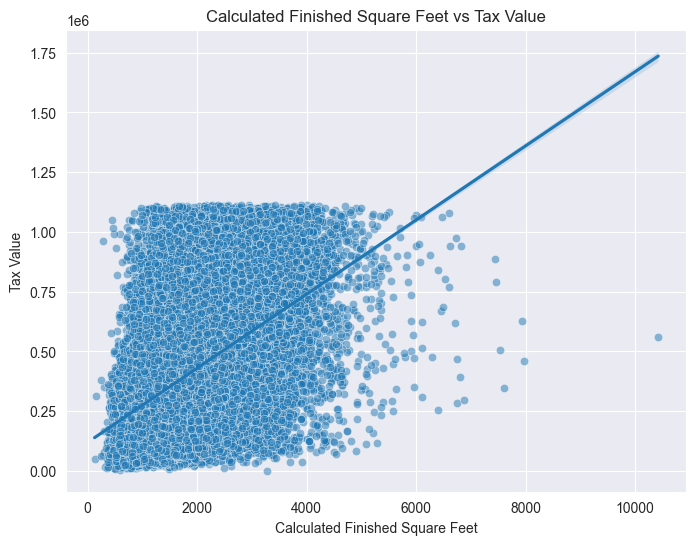

In [108]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='calculatedfinishedsquarefeet', y='taxvaluedollarcnt', alpha=0.5)
sns.regplot(data=df, x='calculatedfinishedsquarefeet', y='taxvaluedollarcnt', scatter=False)
plt.xlabel('Calculated Finished Square Feet')
plt.ylabel('Tax Value')
plt.title('Calculated Finished Square Feet vs Tax Value')
plt.show()

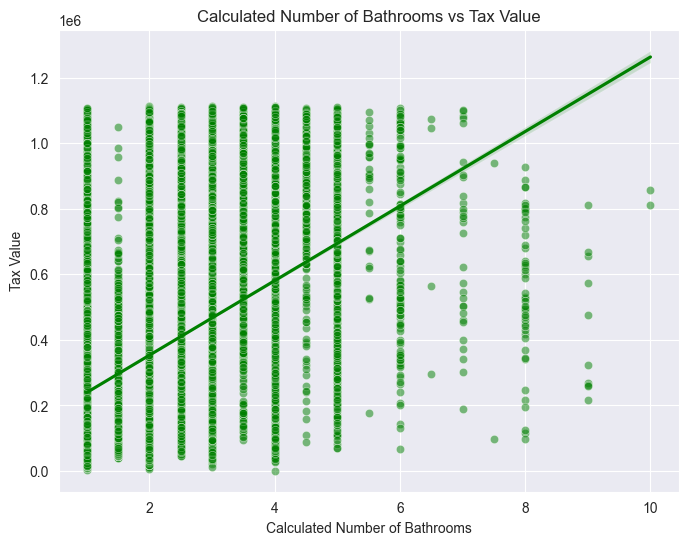

In [109]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='calculatedbathnbr', y='taxvaluedollarcnt', alpha=0.5, color= 'green')
sns.regplot(data=df, x='calculatedbathnbr', y='taxvaluedollarcnt', scatter=False, color= 'green')
plt.xlabel('Calculated Number of Bathrooms')
plt.ylabel('Tax Value')
plt.title('Calculated Number of Bathrooms vs Tax Value')
plt.show()

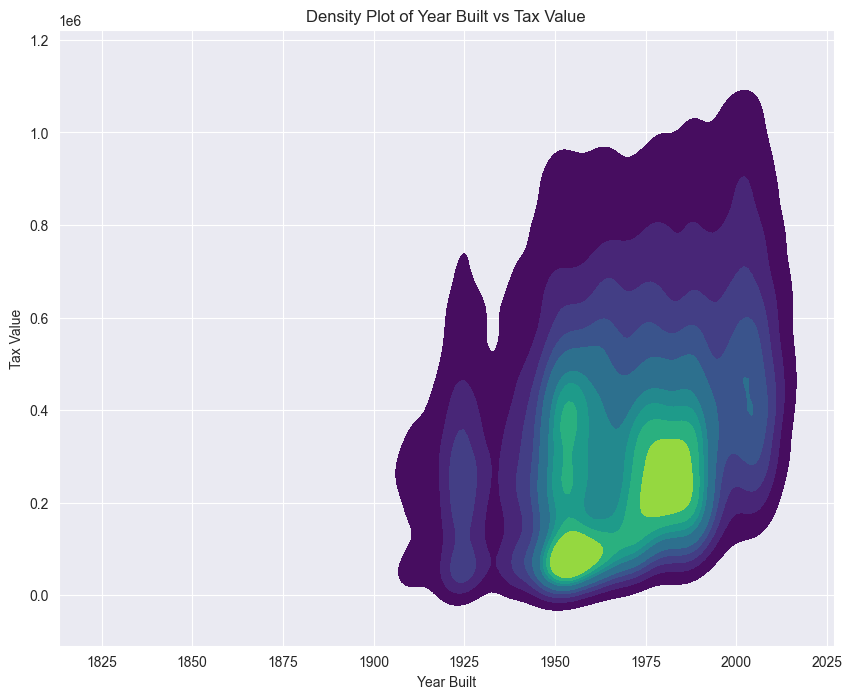

In [110]:
plt.figure(figsize=(10, 8))
sns.kdeplot(x=df['yearbuilt'], y=df['taxvaluedollarcnt'], fill=True, cmap='viridis')
plt.title('Density Plot of Year Built vs Tax Value')
plt.xlabel('Year Built')
plt.ylabel('Tax Value')
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


The Calculated Finished Square Feet vs Tax Value 2D scatter plot shows a positive correlation between the square footage of a property and the total assessed value. We can see that as the finished calculated square footage increases, so does the tax value. Based on this, we can say that larger properties in terms of square feet seem to have higher tax values. However, there are some outliers, in which some properties with high square footage have low tax values. This could suggest that other features play a role here. Thus, there is a linear relationship between the target variable (total assessed value of property) and the calculated finished square feet feature. 
The Calculated Number of Bathrooms vs Tax Value 2D scatter plot shows a positive correlation between the number of bathrooms and the total assessed value of the property. This correlation is not as strong as the plot with the calculated finished square feet feature, but we can still see a positive correlation. The plot shows that as the number of bathrooms increase, so does the tax value. Based on this, we can say that properties with more bathrooms lead to higher tax values. There are some outliers as well, where properties with more bathrooms have low tax values. This suggests that other features may play role here. 
The density plot of the year built and the tax value shows a positive correlation, but it is moderate. We can see that the distibution is quite broad because there is a concentration of properties built around the 1920s to 1950s with high tax values. Also, properties built around 1980s to 2000s have a higher concentration of higher tax values. Based on this, we can say that there is variability in tax values with older properties and newer properties have higher tax values. 

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [129]:
# since 'calculatedfinishedsquarefeet' is right-skewed, we can apply a log transformation to normalize it
df['log_sqft'] = np.log1p(df['calculatedfinishedsquarefeet'])
df['log_taxvalue'] = np.log1p(df['taxvaluedollarcnt'])

# Ratio feature
df['bath_per_sqft'] = df['calculatedbathnbr'] / (df['calculatedfinishedsquarefeet'] + 1)

df['bath_product'] = df['calculatedbathnbr'] * df['bathroomcnt']

transformed_features = ['log_sqft', 'bath_per_sqft', 'bath_product']
correlations = df[transformed_features + ['log_taxvalue']].corr()['log_taxvalue'].drop('log_taxvalue')
# correlations = df[transformed_features + ['calculatedfinishedsquarefeet']].corr()['calculatedfinishedsquarefeet'].drop('calculatedfinishedsquarefeet')
print("Correlation with target:")
print(correlations)

# F-score 
X = df[transformed_features]
y = df['log_taxvalue']
# y = df['calculatedfinishedsquarefeet']
f_scores, _ = f_regression(X.fillna(0), y)
f_scores_df = pd.Series(f_scores, index=transformed_features).sort_values(ascending=False)

print("\nF-scores:")
print(f_scores_df)

Correlation with target:
log_sqft         0.399981
bath_per_sqft   -0.051490
bath_product     0.331369
Name: log_taxvalue, dtype: float64

F-scores:
log_sqft         13787.035964
bath_product      8929.282354
bath_per_sqft      192.433398
dtype: float64


In [130]:
df['room_size_interaction'] = df['bedroomcnt'] * df['calculatedfinishedsquarefeet']
df.loc[df['room_size_interaction'] > 0, 'log_room_size'] = np.log1p(df.loc[df['room_size_interaction'] > 0, 'room_size_interaction'])

df['age_squared'] = (2025 - df['yearbuilt'])**2

In [133]:
correlation = df[['log_room_size', 'age_squared', 'log_taxvalue']].corr()['log_taxvalue'].drop('log_taxvalue')
print("Correlation with log-taxvalue:")
print(correlation)

X_new = df[['log_room_size', 'age_squared']].fillna(0)
y_new = df['log_taxvalue']

f_scores, _ = f_regression(X_new, y_new)
f_scores_series = pd.Series(f_scores, index=X_new.columns).sort_values(ascending=False)

print("F-score:")
print(f_scores_series)

Correlation with log-taxvalue:
log_room_size    0.322011
age_squared     -0.233577
Name: log_taxvalue, dtype: float64
F-score:
age_squared      4177.380147
log_room_size    3593.224713
dtype: float64


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


Since both 'calculatedfinishedsquarefeet' and 'taxvaluedollarcnt' are right-skewed, it means there would be some extreme points (which are outliers) out there. We need to reduce the frequency of such occurrences, so we use log transformation to shrink the extreme range. and make it closer to the normal distribution. Ratio and interaction features like bath_per_sqft, bath_product and logged room_size_interaction, this non-linear relationship, it can help model to fit better on a complex dataset, lower bias and improve the prediction accuracy. Evaluation based on the correlation and F-score, it can be told that bath_per_sqft is not very helpful because it has the lowest F-score and weak correlation with log-taxvalue. Other than that, log_sqft, bath_product and age_squared are helpful. The log_sqft shrinks the extreme range and makes it to the normal distribution, strong correlation with log-taxvalue and highest F-score. Even though the correlation with log-taxvalue is negative and F-score is not too high for age_squared, it still can be told that the newer houses will be expensive, the older houses will be cheaper.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

